# Distortion Map Generation via Optimal Transport
Generates displacement fields that warp source density distributions to target distributions.

In [ ]:
import re
import numpy as np
import torch
import ot
import matplotlib.pyplot as plt
from matplotlib import colors
from pathlib import Path
from PIL import Image

# Configuration
OUTPUT_FOLDER = Path("C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig/distortion_maps")
INPUT_FOLDER = Path("C:/Users/ckobalt/Documents/MasterThesis/Spatially-Varying-Bokeh/bokehConfig/2_cropped")
RESOLUTION = (64, 64)  # (height, width)
MAX_ITERS = 2_000
LR = 1e-4
LOG_INTERVAL = 200

# Regularization weights
SMOOTHNESS_WEIGHT = 5e-2
MAGNITUDE_WEIGHT = 2e-3
MID_WEIGHT = 2.0

## Utility Functions

In [83]:
def load_gray(path: Path, resolution: tuple[int, int] | None = None, *, invert: bool = False) -> np.ndarray:
    """Load grayscale image, optionally resizing to (height, width)."""
    with Image.open(path) as img:
        if resolution is not None:
            h, w = resolution
            if img.size != (w, h):
                img = img.resize((w, h), resample=Image.BILINEAR)
        arr = np.asarray(img, dtype=np.float64)
        return (255.0 - arr) if invert else arr

def normalize_density(arr: np.ndarray) -> np.ndarray:
    """Clip negative values and normalize to sum to 1."""
    arr = np.clip(arr, 0, None)
    return arr / arr.sum()

def make_grid_coords(height: int, width: int) -> np.ndarray:
    """Create normalized [-1, 1] coordinate grid of shape (H, W, 2)."""
    gy, gx = np.meshgrid(np.linspace(-1, 1, height), np.linspace(-1, 1, width), indexing="ij")
    return np.stack((gy, gx), axis=-1)

def save_distortion_map(coords: np.ndarray, path: Path):
    """Save (y, x) coordinate map as RGB image (R=x, G=y, B=0)."""
    path.parent.mkdir(parents=True, exist_ok=True)
    uint8 = ((np.stack((coords[..., 1], coords[..., 0]), axis=-1) + 1.0) * 127.5).clip(0, 255).astype(np.uint8)
    rgb = np.zeros((*coords.shape[:2], 3), dtype=np.uint8)
    rgb[..., :2] = uint8
    Image.fromarray(rgb, mode="RGB").save(path)
    print(f"Saved: {path}")

def load_displacement_field(path: Path, source_coords: np.ndarray) -> np.ndarray:
    """Load distortion map and convert to displacement field."""
    dest = (np.asarray(Image.open(path), dtype=np.float32)[..., :2] / 127.5) - 1.0
    dest_coords = np.stack((dest[..., 1], dest[..., 0]), axis=-1)
    return dest_coords - source_coords

def apply_field(points: np.ndarray, field: np.ndarray) -> np.ndarray:
    """Apply displacement field to points using nearest-neighbor lookup."""
    h, w = field.shape[:2]
    pts = points.reshape(-1, 2)
    norm = np.clip((pts + 1.0) / 2.0, 0.0, 0.999999)
    idx = (norm * [h - 1, w - 1]).astype(int)
    return np.clip(pts + field[idx[:, 0], idx[:, 1]], -1.0, 1.0).reshape(points.shape)

def glob_sorted(folder: Path, pattern: str) -> list[Path]:
    """Glob files and sort by numeric suffix."""
    return sorted(folder.glob(pattern), key=lambda p: int(re.search(r"(\d+)", p.name).group(1)))

## Visualization

In [84]:
class LiveLossPlot:
    """Live-updating stacked area plot for optimization loss components."""
    
    COMPONENT_COLORS = {
        "target": ("#2ecc71", "Target"),
        "mid": ("#3498db", "Midpoint"),
        "smooth": ("#e74c3c", "Smoothness"),
        "mag": ("#9b59b6", "Magnitude"),
    }
    
    def __init__(self, figsize=(8, 3)):
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.display_handle = display(self.fig, display_id=True)
    
    def update(self, loss_history: dict, step: int):
        """Update plot with current loss history."""
        self.ax.clear()
        x = np.arange(len(loss_history["total"]))
        
        # Build stacked components (only include non-zero ones)
        components, labels, colors_list = [], [], []
        for key, (color, label) in self.COMPONENT_COLORS.items():
            if key in loss_history and any(v > 0 for v in loss_history[key]):
                components.append(loss_history[key])
                labels.append(label)
                colors_list.append(color)
        
        if components:
            self.ax.stackplot(x, *components, labels=labels, colors=colors_list, alpha=0.7)
        
        # Total loss line on top
        self.ax.plot(x, loss_history["total"], 'k-', lw=1, label='Total', zorder=10)
        
        self.ax.set_xlabel('Iteration')
        self.ax.set_ylabel('Loss')
        self.ax.set_title(f'Optimization Progress - Iter {step + 1}, Loss: {loss_history["total"][-1]:.6f}')
        self.ax.grid(True, alpha=0.3)
        self.ax.legend(loc='upper right', fontsize=8)
        self.ax.set_xlim(0, max(len(loss_history["total"]), 10))
        self.ax.set_ylim(0, max(loss_history["total"]) * 1.1 if loss_history["total"] else 1)
        
        self.display_handle.update(self.fig)
    
    def close(self):
        plt.close(self.fig)


def plot_density_panels(panels: list[tuple[str, np.ndarray]]):
    """Plot multiple density maps side by side with shared colorbar."""
    if not panels:
        return
    norm = colors.Normalize(vmin=min(p.min() for _, p in panels), vmax=max(p.max() for _, p in panels))
    fig, axes = plt.subplots(1, len(panels), figsize=(4 * len(panels), 3.5))
    axes = [axes] if len(panels) == 1 else axes
    for ax, (title, data) in zip(axes, panels):
        im = ax.imshow(data, origin="lower", extent=[-1, 1, -1, 1], cmap="magma", norm=norm)
        ax.set_title(title)
    fig.colorbar(im, ax=axes, shrink=0.8)
    plt.tight_layout()
    plt.show()

def plot_distortion_vectors(distortion_path: Path, *, title: str | None = None):
    """Visualize displacement vectors from a distortion map."""
    dest = (np.asarray(Image.open(distortion_path), dtype=np.float32)[..., :2] / 127.5) - 1.0
    dest_coords = np.stack((dest[..., 1], dest[..., 0]), axis=-1)
    height, width = dest_coords.shape[:2]
    source_coords = make_grid_coords(height, width)
    disp = dest_coords - source_coords
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.quiver(source_coords[..., 1], source_coords[..., 0], disp[..., 1], disp[..., 0],
              angles='xy', color='blue', alpha=0.6, width=0.003)
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.set_title(title or distortion_path.name)
    plt.tight_layout()
    plt.show()

## Core Optimization

In [85]:
from IPython.display import display, clear_output

def solve_ot_displacement(source_coords: np.ndarray, source_mass: np.ndarray, target_mass: np.ndarray) -> np.ndarray:
    """Compute initial displacement field using exact optimal transport (EMD)."""
    flat_coords = source_coords.reshape(-1, 2)
    cost_matrix = ot.dist(flat_coords, flat_coords, metric='sqeuclidean')
    plan = ot.emd(source_mass.ravel(), target_mass.ravel(), cost_matrix)
    row_mass = plan.sum(axis=1)
    expected_targets = np.where((row_mass > 1e-9)[:, None], (plan @ flat_coords) / row_mass[:, None], flat_coords)
    return (expected_targets - flat_coords).reshape(*source_coords.shape)

def refine_density_with_adam(
    source_coords: np.ndarray, source_density: np.ndarray, target_density: np.ndarray, *,
    init_field: np.ndarray | None = None, mid_density: np.ndarray | None = None,
    mid_weight: float = 1.0, smoothness_weight: float = 0.0, magnitude_weight: float = 0.0,
    lr: float = 1e-3, max_iters: int = 10_000, log_interval: int = 200,
    device: torch.device | None = None,
) -> dict:
    """Refine displacement field using Adam to match pushed-forward density to target."""
    height, width = source_density.shape
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    coords_t = torch.from_numpy(source_coords.astype(np.float32)).to(device)
    source_t = torch.from_numpy(source_density.astype(np.float32)).to(device)
    target_t = torch.from_numpy(target_density.astype(np.float32)).to(device)
    
    base_field = torch.from_numpy(init_field.astype(np.float32)).to(device) if init_field is not None else torch.zeros_like(coords_t)
    field = torch.nn.Parameter(base_field.clone())
    optimizer = torch.optim.Adam([field], lr=lr)
    
    mid_t = torch.from_numpy(mid_density.astype(np.float32)).to(device) if mid_density is not None else None

    def push_forward(f: torch.Tensor, scale: float = 1.0) -> torch.Tensor:
        distorted = coords_t + f * scale
        dx = ((distorted[..., 1] + 1.0) * 0.5 * (width - 1)).clamp(0.0, width - 1.0)
        dy = ((distorted[..., 0] + 1.0) * 0.5 * (height - 1)).clamp(0.0, height - 1.0)
        x0, y0 = dx.floor().long(), dy.floor().long()
        x1, y1 = (x0 + 1).clamp(max=width - 1), (y0 + 1).clamp(max=height - 1)
        wx, wy = dx - x0.float(), dy - y0.float()
        w00, w10, w01, w11 = (1 - wx) * (1 - wy), wx * (1 - wy), (1 - wx) * wy, wx * wy
        flat_mass = source_t.reshape(-1)
        out = torch.zeros_like(flat_mass)
        for w, yi, xi in [(w00, y0, x0), (w10, y0, x1), (w01, y1, x0), (w11, y1, x1)]:
            out.scatter_add_(0, (yi * width + xi).reshape(-1), flat_mass * w.reshape(-1))
        return out.view(height, width) / out.sum().clamp_min(1e-12)

    def smoothness_loss(f: torch.Tensor) -> torch.Tensor:
        if f.shape[0] > 1 and f.shape[1] > 1:
            return (f[1:] - f[:-1]).pow(2).mean() + (f[:, 1:] - f[:, :-1]).pow(2).mean()
        return torch.tensor(0.0, device=device)

    def movement_cost(f: torch.Tensor) -> torch.Tensor:
        """Mass-weighted squared displacement: sum_i m_i * ||d_i||^2"""
        disp_sq = f.pow(2).sum(dim=-1)  # ||d_i||^2 per pixel
        return (source_t * disp_sq).sum()  # weight by source mass

    # Track individual loss components
    loss_history = {"total": [], "target": [], "mid": [], "smooth": [], "mag": []}
    
    with torch.no_grad():
        initial = push_forward(base_field)
        mid_initial = push_forward(base_field, 0.5) if mid_t is not None else None
        baseline_loss = float(torch.nn.functional.l1_loss(initial, target_t))

    plot = LiveLossPlot()

    for step in range(max_iters):
        optimizer.zero_grad()
        
        # Compute individual loss components
        target_loss = torch.nn.functional.l1_loss(push_forward(field), target_t)
        mid_loss = mid_weight * torch.nn.functional.l1_loss(push_forward(field, 0.5), mid_t) if mid_t is not None else torch.tensor(0.0, device=device)
        smooth_loss = smoothness_weight * smoothness_loss(field) if smoothness_weight > 0 else torch.tensor(0.0, device=device)
        mag_loss = magnitude_weight * movement_cost(field) if magnitude_weight > 0 else torch.tensor(0.0, device=device)
        
        loss = target_loss + mid_loss + smooth_loss + mag_loss
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            field.data.copy_(torch.clamp(coords_t + field.data, -1.0, 1.0) - coords_t)
        
        # Store individual components
        loss_history["total"].append(float(loss))
        loss_history["target"].append(float(target_loss))
        loss_history["mid"].append(float(mid_loss))
        loss_history["smooth"].append(float(smooth_loss))
        loss_history["mag"].append(float(mag_loss))
        
        if log_interval and (step == 0 or (step + 1) % log_interval == 0):
            plot.update(loss_history, step)

    plot.close()

    with torch.no_grad():
        final = push_forward(field)
        mid_final = push_forward(field, 0.5) if mid_t is not None else None
    
    result = {
        "field": field.detach().cpu().numpy(),
        "expected_initial": initial.cpu().numpy(),
        "expected_final": final.cpu().numpy(),
        "loss_history": loss_history,
        "baseline_loss": baseline_loss,
        "final_loss": loss_history["total"][-1] if loss_history["total"] else baseline_loss,
    }
    
    # Add midpoint results if midpoint was used
    if mid_t is not None:
        result["mid_initial"] = mid_initial.cpu().numpy()
        result["mid_final"] = mid_final.cpu().numpy()
    
    return result

## Main Processing

In [86]:
def create_distortion_map(
    path_a: Path, path_b: Path, output_path: Path, *,
    resolution: tuple[int, int] = RESOLUTION,
    source_override: np.ndarray | None = None,
    midpoint_path: Path | None = None,
    invert: bool = False,
    lr: float = LR, max_iters: int = MAX_ITERS, log_interval: int = LOG_INTERVAL,
    mid_weight: float = MID_WEIGHT, smoothness_weight: float = SMOOTHNESS_WEIGHT,
    magnitude_weight: float = MAGNITUDE_WEIGHT, show_plots: bool = True,
) -> np.ndarray:
    """Create distortion map from source to target density using optimal transport + refinement."""
    # Load and normalize densities
    density_a = source_override if source_override is not None else load_gray(path_a, resolution, invert=invert)
    density_b = load_gray(path_b, resolution, invert=invert)
    source_mass = normalize_density(density_a)
    target_mass = normalize_density(density_b)
    
    source_coords = make_grid_coords(*density_a.shape)
    
    # Initial OT solution + Adam refinement
    init_field = solve_ot_displacement(source_coords, source_mass, target_mass)
    
    mid_density = normalize_density(load_gray(midpoint_path, resolution, invert=invert)) if midpoint_path else None
    
    result = refine_density_with_adam(
        source_coords, source_mass, target_mass,
        init_field=init_field, mid_density=mid_density,
        lr=lr, max_iters=max_iters, log_interval=log_interval,
        mid_weight=mid_weight, smoothness_weight=smoothness_weight, magnitude_weight=magnitude_weight,
    )
    print(f"Loss: {result['baseline_loss']:.6f} → {result['final_loss']:.6f}")
    
    if show_plots:
        # Main target density panels
        plot_density_panels([("Source", source_mass), ("Target", target_mass),
                            ("OT initial", result["expected_initial"]), ("Refined", result["expected_final"])])
        
        # Midpoint density panels (if midpoint was used)
        if mid_density is not None and "mid_initial" in result:
            plot_density_panels([("Mid Target", mid_density),
                                ("Mid OT initial", result["mid_initial"]), ("Mid Refined", result["mid_final"])])
    
    save_distortion_map(source_coords + result["field"], output_path)
    return result["expected_final"]

## Generate Incremental Distortion Maps

Found 13 bokeh images: indices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Saved: C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_0.png

=== Map 1: idx 0 → 2 ===
Using device: cpu


C:\Users\ckobalt\AppData\Local\Temp\1\ipykernel_39048\3150948483.py:9: RuntimeWarning: invalid value encountered in divide
  expected_targets = np.where((row_mass > 1e-9)[:, None], (plan @ flat_coords) / row_mass[:, None], flat_coords)


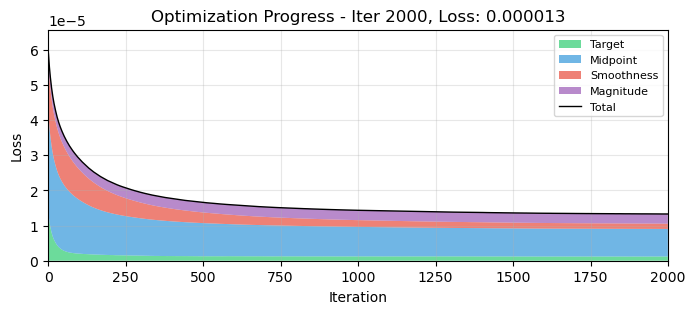

Loss: 0.000014 → 0.000013


C:\Users\ckobalt\AppData\Local\Temp\1\ipykernel_39048\3631415779.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


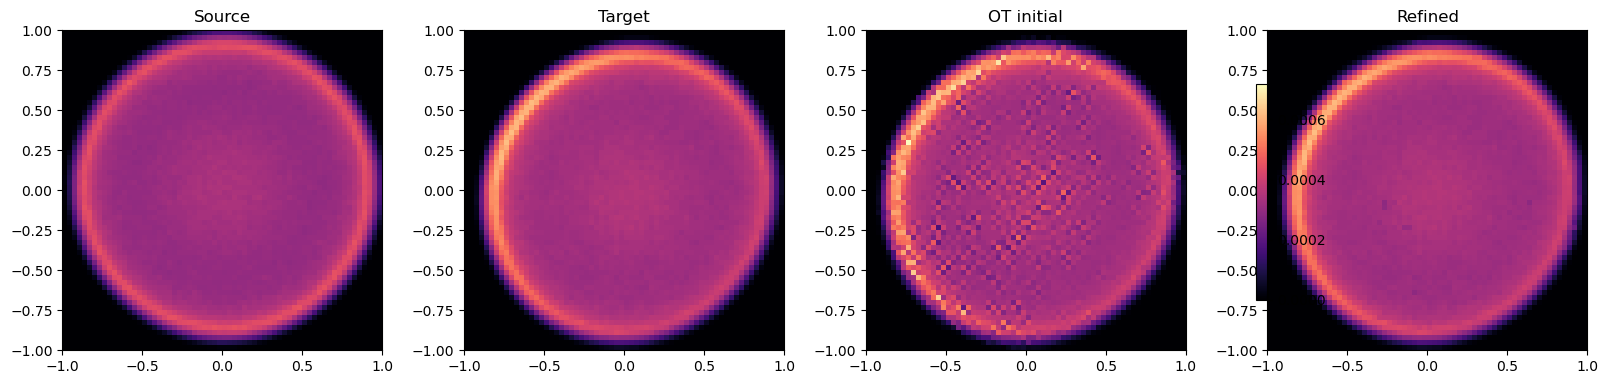

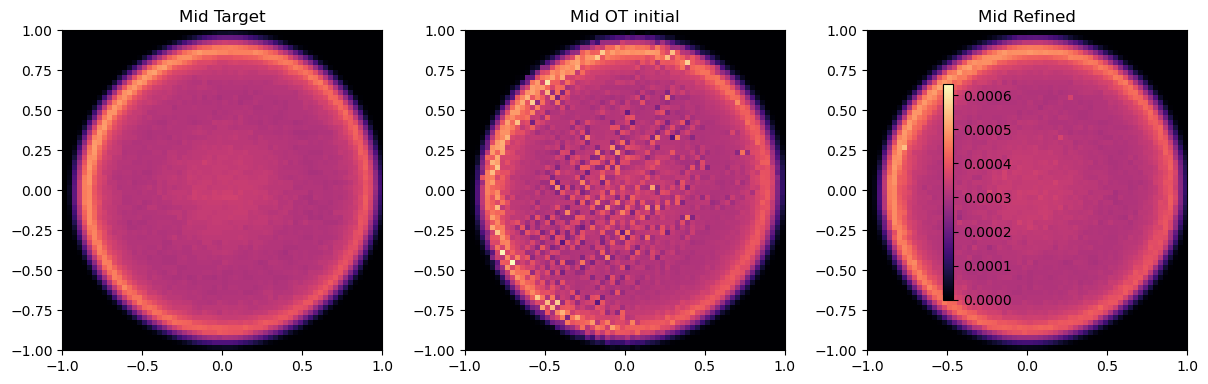

Saved: C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\incremental\distortion_map_1.png

=== Map 2: idx 2 → 4 ===
Using device: cpu


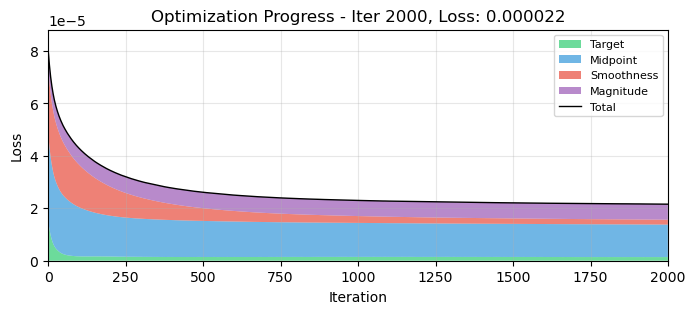

Loss: 0.000015 → 0.000022


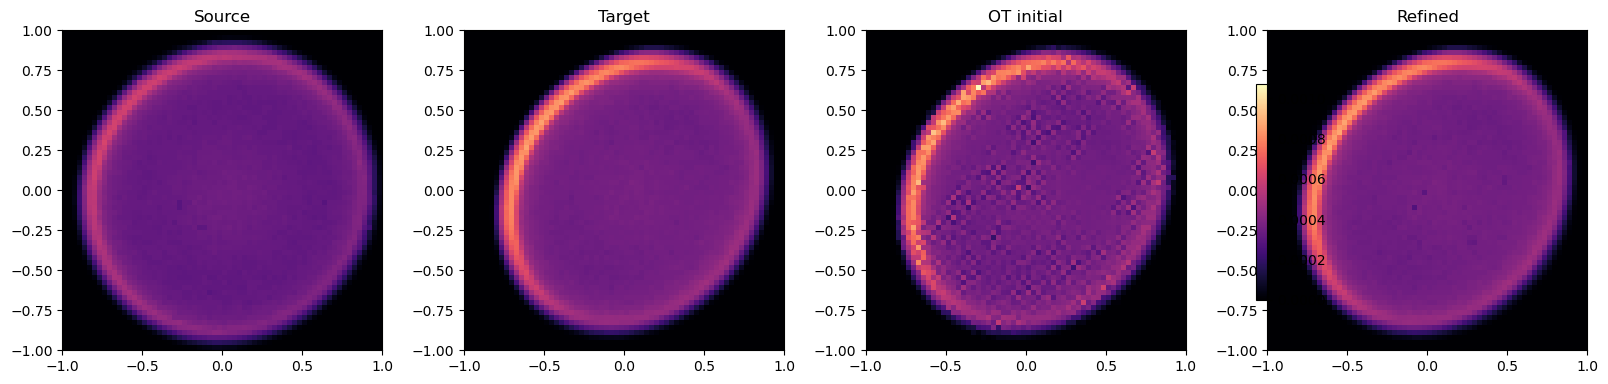

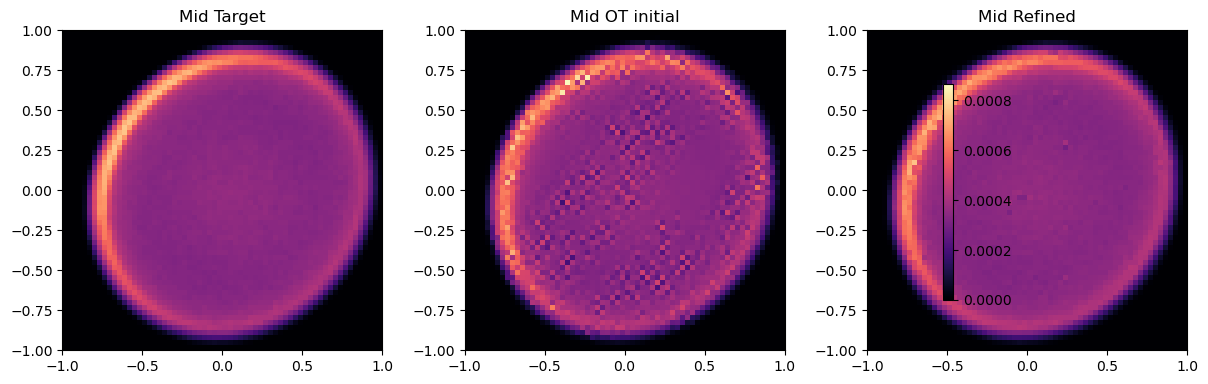

Saved: C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\incremental\distortion_map_2.png

=== Map 3: idx 4 → 6 ===
Using device: cpu


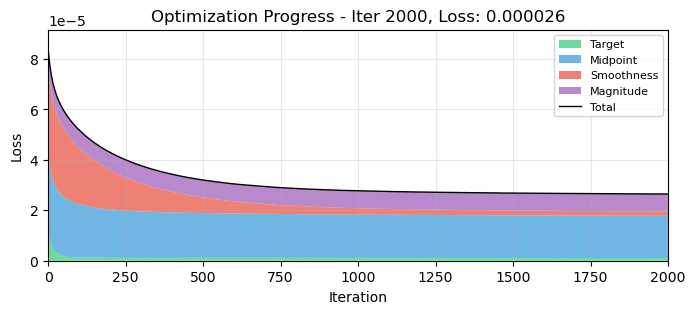

Loss: 0.000011 → 0.000026


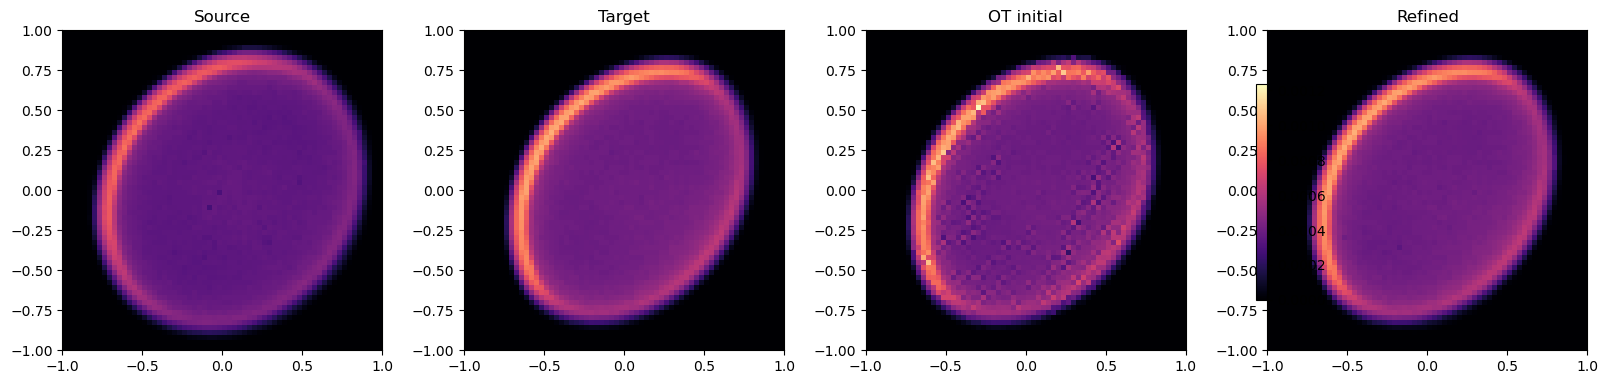

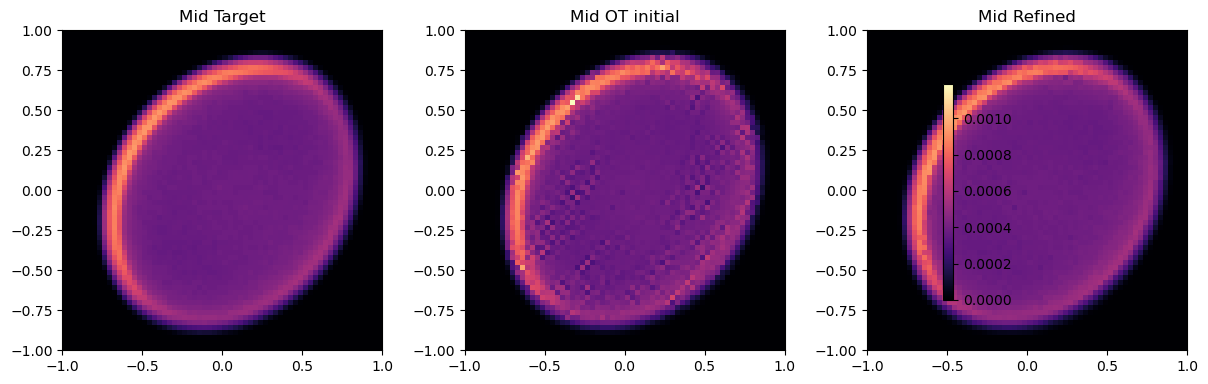

Saved: C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\incremental\distortion_map_3.png

=== Map 4: idx 6 → 8 ===
Using device: cpu


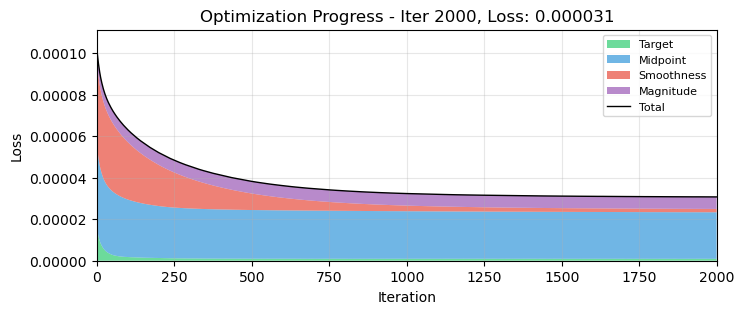

Loss: 0.000015 → 0.000031


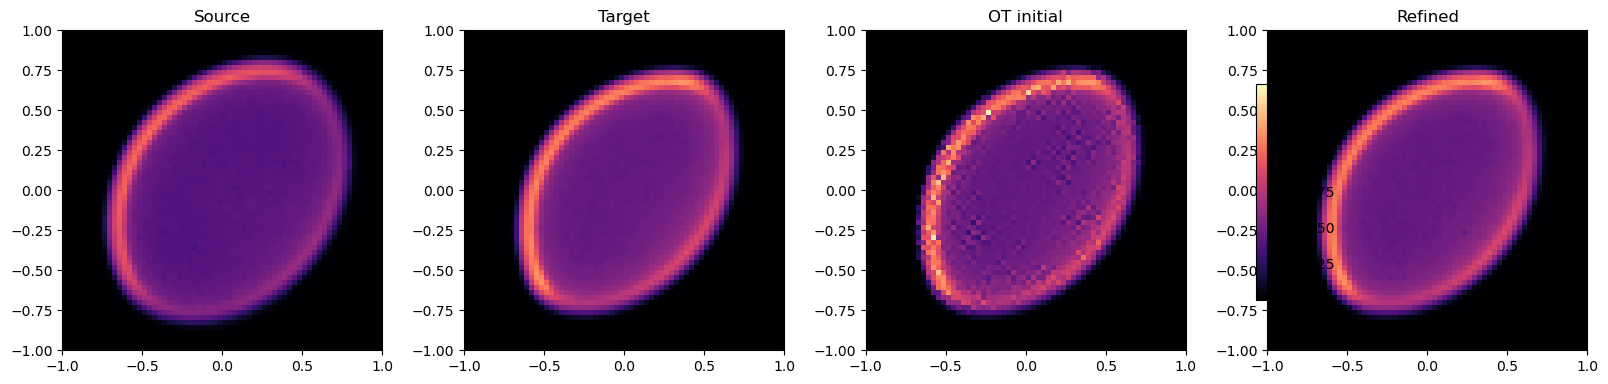

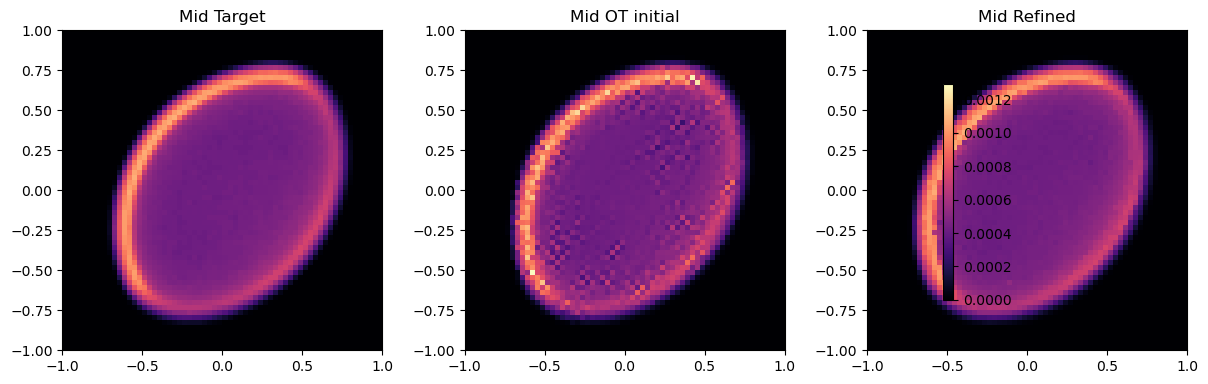

Saved: C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\incremental\distortion_map_4.png

=== Map 5: idx 8 → 10 ===
Using device: cpu


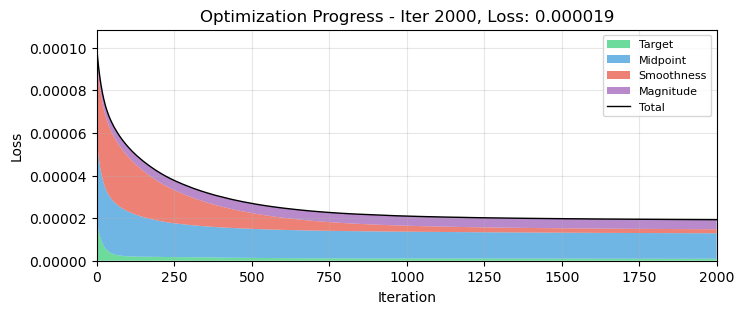

Loss: 0.000018 → 0.000019


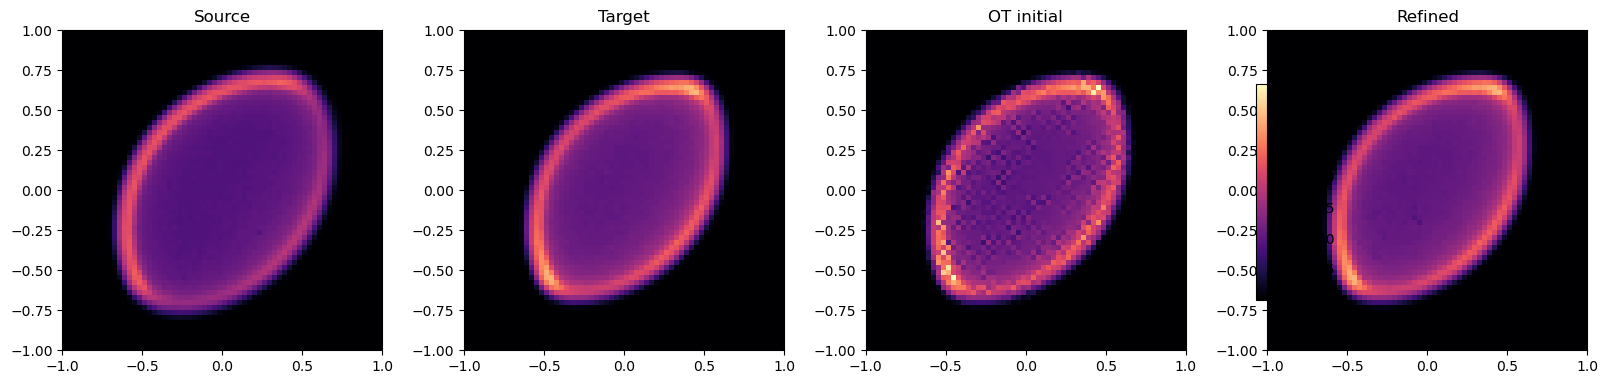

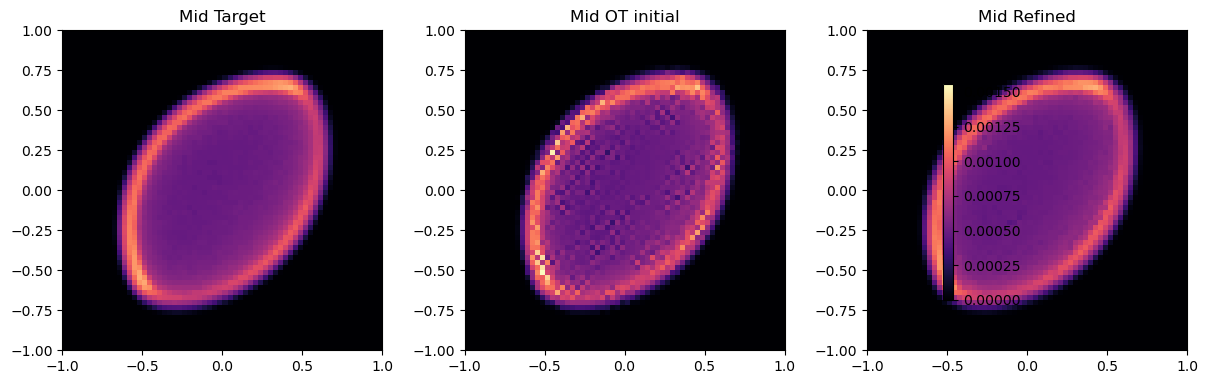

Saved: C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\incremental\distortion_map_5.png

=== Map 6: idx 10 → 12 ===
Using device: cpu


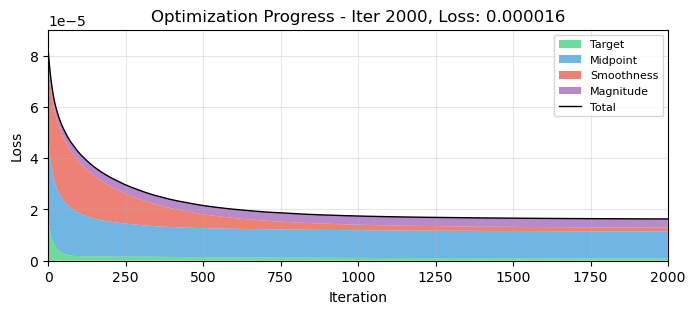

Loss: 0.000016 → 0.000016


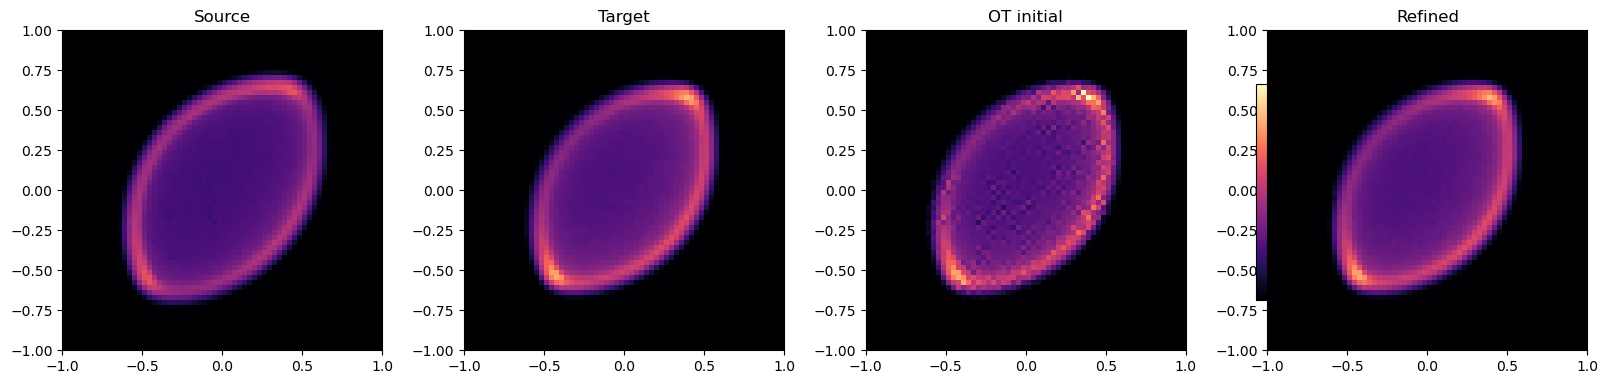

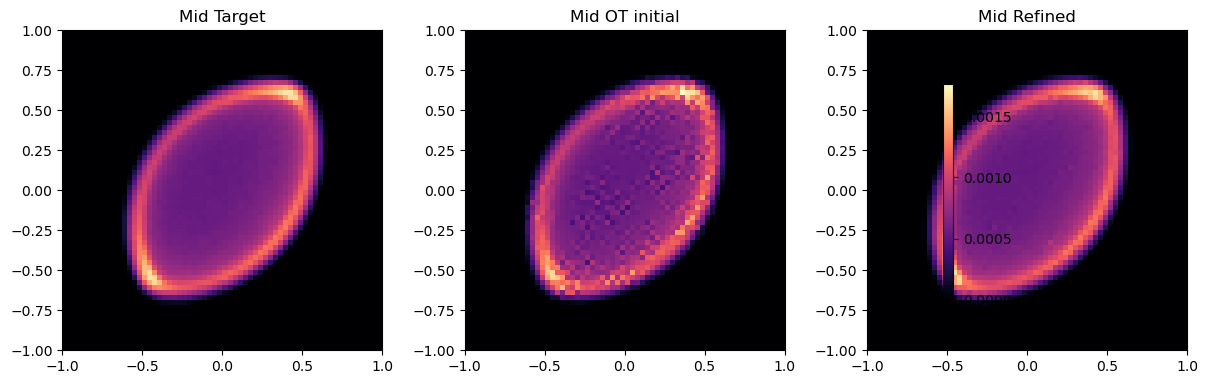

Saved: C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\incremental\distortion_map_6.png


In [87]:
# Find bokeh images matching pattern: bokeh_*{i}of{j}.pgm
bokeh_pattern = re.compile(r"^bokeh_.*?(\d+)of(\d+)\.pgm$")
all_paths = {}
for p in INPUT_FOLDER.glob("bokeh_*.pgm"):
    if m := bokeh_pattern.match(p.name):
        i = int(m.group(1))
        all_paths[i] = p
all_paths = dict(sorted(all_paths.items()))
print(f"Found {len(all_paths)} bokeh images: indices {list(all_paths.keys())}")

# Save identity map (index 0)
identity_coords = make_grid_coords(*RESOLUTION)
save_distortion_map(identity_coords, OUTPUT_FOLDER / "distortion_map_0.png")

# Generate incremental maps (0→2, 2→4, ..., skipping by 2)
indices = sorted(all_paths.keys())
refined_source = None
map_index = 1
for i in range(0, len(indices) - 2, 2):
    start_idx, mid_idx, end_idx = indices[i], indices[i + 1], indices[i + 2]
    print(f"\n=== Map {map_index}: idx {start_idx} → {end_idx} ===")
    refined_source = create_distortion_map(
        all_paths[start_idx], all_paths[end_idx],
        OUTPUT_FOLDER / "incremental" / f"distortion_map_{map_index}.png",
        source_override=refined_source,
        midpoint_path=all_paths.get(mid_idx),
        invert=True,  # PGM files are inverted
    )
    map_index += 1

## Compose Cumulative Distortion Maps

In [88]:
incremental_maps = glob_sorted(OUTPUT_FOLDER / "incremental", "distortion_map_*.png")
print(f"Found {len(incremental_maps)} incremental maps")

# Compose into cumulative maps
source_coords = make_grid_coords(*RESOLUTION)
running = np.zeros_like(source_coords)

for map_path in incremental_maps:
    idx = int(re.search(r"(\d+)", map_path.name).group(1))
    field = load_displacement_field(map_path, source_coords)
    running = apply_field(source_coords + running, field) - source_coords
    save_distortion_map(np.clip(source_coords + running, -1.0, 1.0), OUTPUT_FOLDER / f"distortion_map_{idx}.png")

Found 6 incremental maps
Saved: C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_1.png
Saved: C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_2.png
Saved: C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_3.png
Saved: C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_4.png
Saved: C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_5.png
Saved: C:\Users\ckobalt\Documents\MasterThesis\Spatially-Varying-Bokeh\bokehConfig\distortion_maps\distortion_map_6.png


## Visualize Results
### Incremental Maps

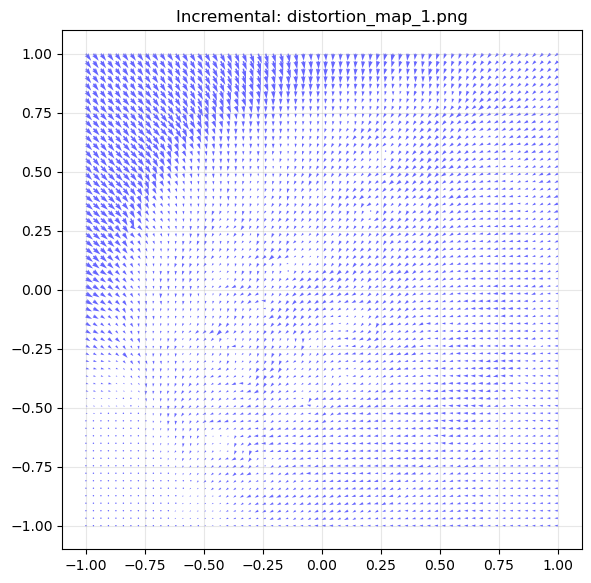

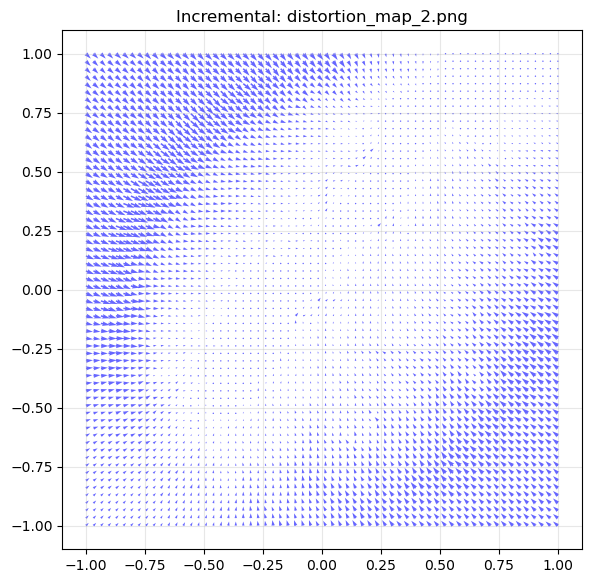

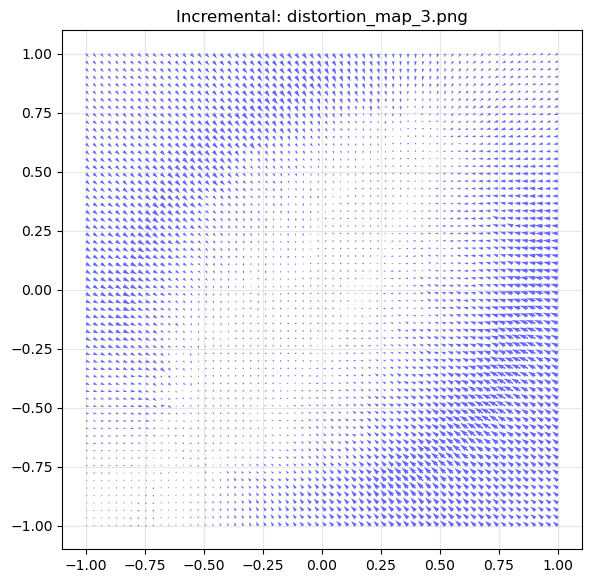

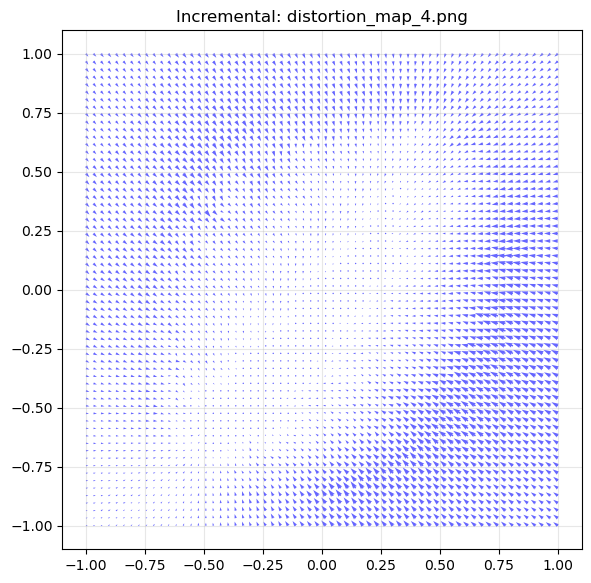

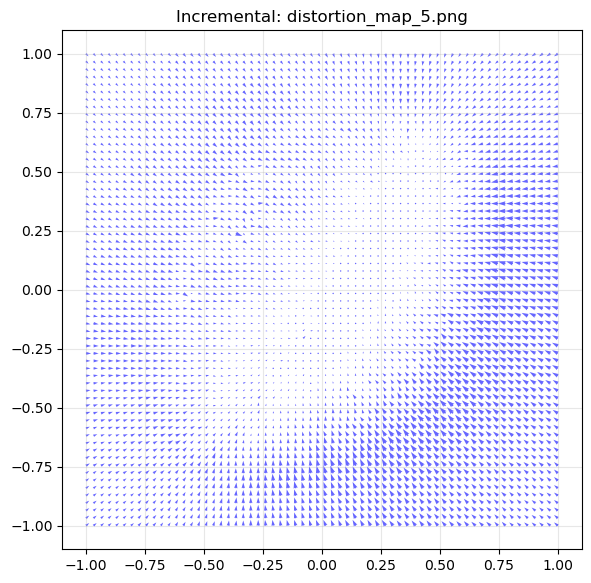

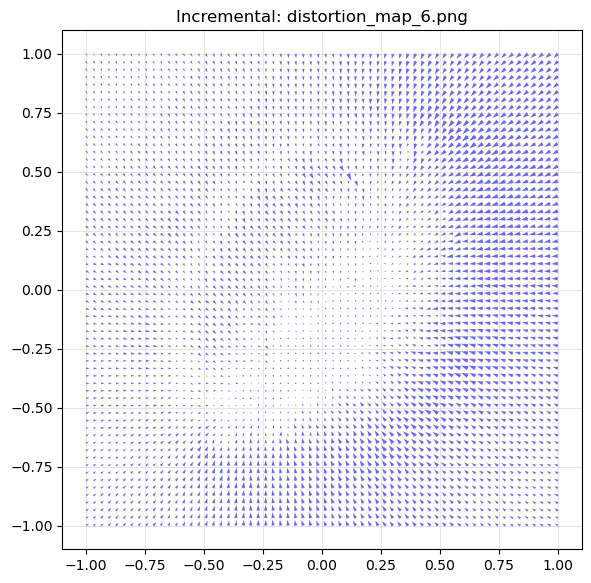

In [89]:
for p in glob_sorted(OUTPUT_FOLDER / "incremental", "distortion_map_*.png"):
    plot_distortion_vectors(p, title=f"Incremental: {p.name}")

### Cumulative Maps

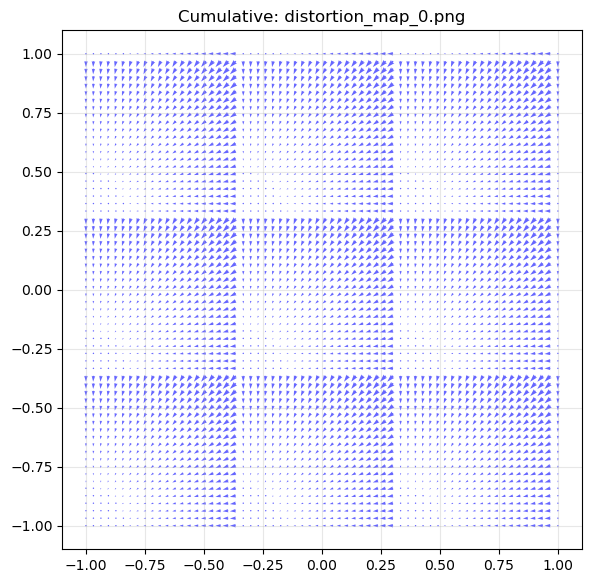

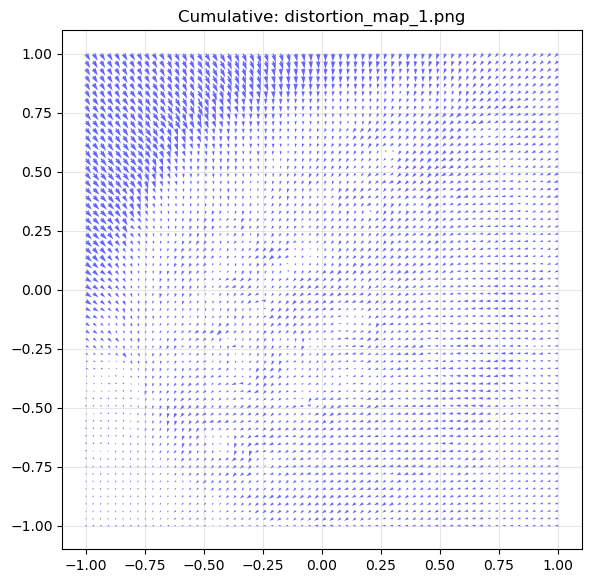

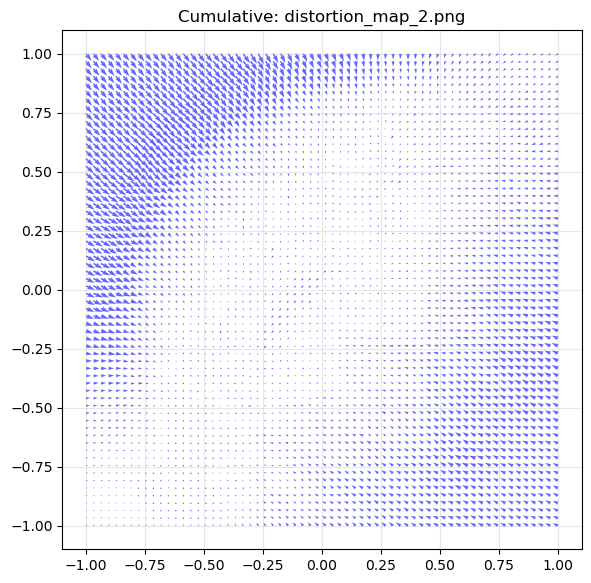

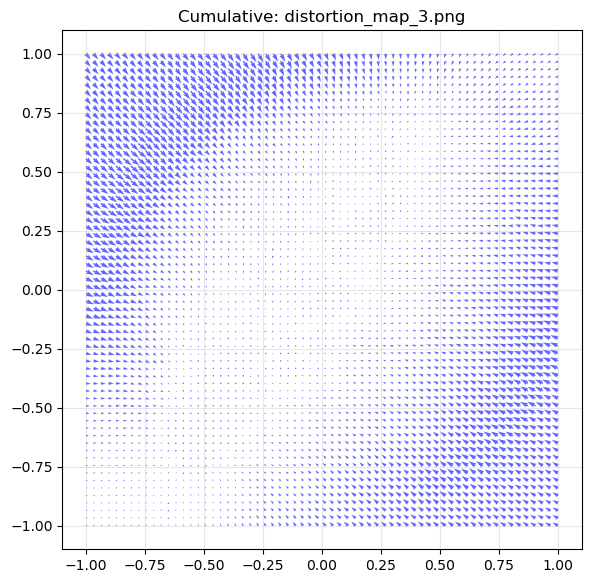

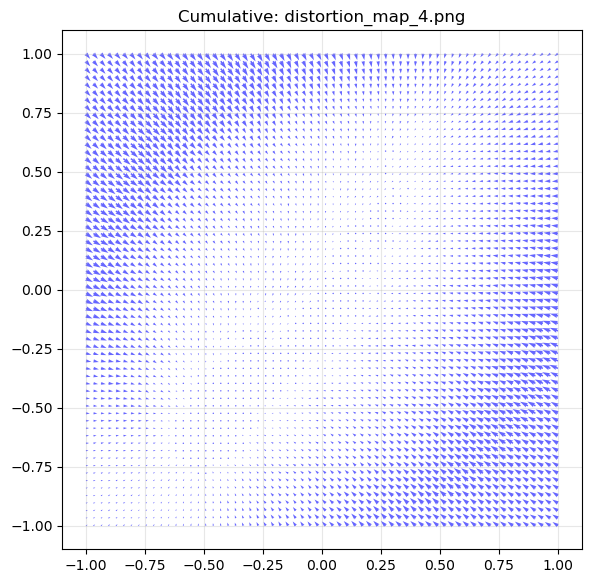

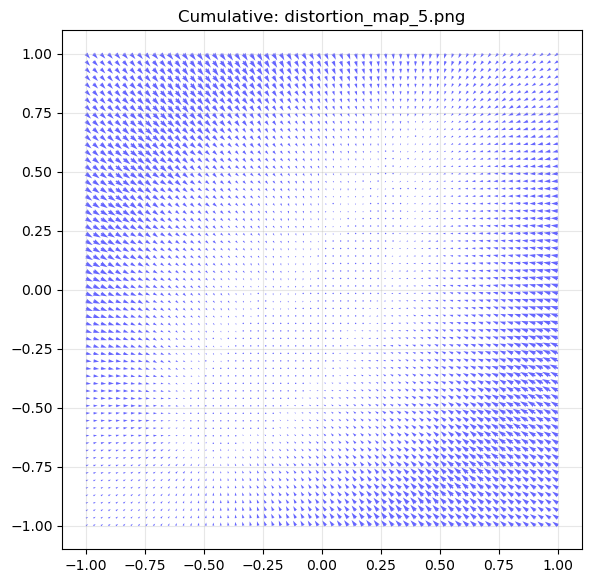

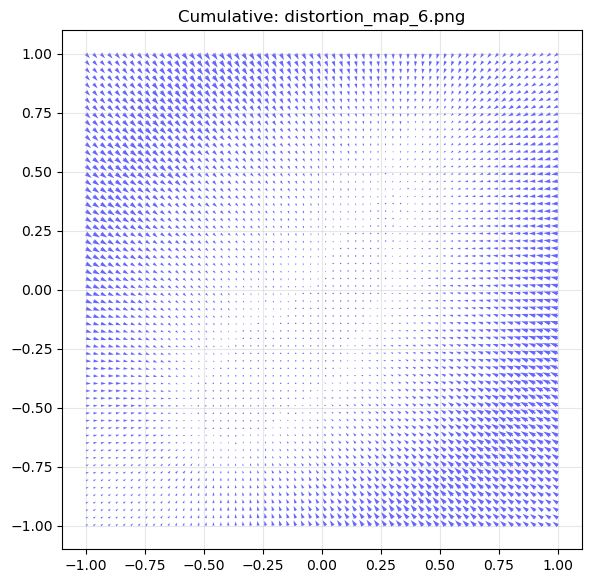

In [90]:
for p in glob_sorted(OUTPUT_FOLDER, "distortion_map_*.png"):
    plot_distortion_vectors(p, title=f"Cumulative: {p.name}")